In [114]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 19 — GRRR gauge correlation analysis

Compares Google GRRR and GloFAS reanalysis streamflow against Floodscan SFED (Surface Water Extent Deviation) across all gauges within the target state's flood-affected LGAs. The goal is to identify which gauges are most predictive of Floodscan flooding, and to select a top-10 set for use as an action trigger.

**Parameterise** by setting `STATE` in the config cell below (`"Adamawa"` or `"Benue"`). Re-run for each state to update the blob.

---

## Methodology

- **Gauge discovery**: all GRRR gauges (including non-quality-verified) whose catchment intersects the selected LGAs, via `grrr.get_gauges_by_area()`
- **Correlation metric**: Spearman ρ between raw wet-season (Aug–Nov) daily streamflow and daily mean Floodscan SFED, computed across a lag range of [−7, +14] days. Raw values are used (not deseasonalised) to preserve the shared seasonal cycle
- **Annual peak diagnostics**: Spearman ρ on wet-season annual maxima, plus mean peak timing difference (gauge peak DOY − Floodscan peak DOY), to check whether high daily correlation holds at extreme events
- **Top-10 selection**: gauges ranked by best Spearman ρ; top 10 used as the action trigger input in `20_trigger_tuning.ipynb`

## Outputs

All gauges (with `top_10` flag and lat/lon) are saved to blob storage for use by the dashboard:
```
ds-aa-nga-flooding/processed/model_comparison/{state}_top10_gauges.parquet
```

In [115]:
import matplotlib.pyplot as plt
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from dotenv import load_dotenv
from scipy import stats as scipy_stats

from src.constants import STATE_CONFIG
from src.datasources import grrr
from src.datasources.glofas import GF_STATIONS, get_blob_name

load_dotenv()

True

In [116]:
# ── Config ────────────────────────────────────────────────────────────────────
STATE = "Adamawa"  # "Adamawa" or "Benue"

WET_MONTHS = [8, 9, 10, 11]  # Aug–Nov
MIN_LAG = -7
MAX_LAG = 14
MIN_OBS = 60

cfg = STATE_CONFIG[STATE]
ANALYSIS_START_YEAR = cfg["analysis_start_year"]
ANALYSIS_END_YEAR = cfg["analysis_end_year"]
FIGURES_DIR = "figures"

## Load data

In [117]:
df_fs_raw = stratus.load_parquet_from_blob(cfg["floodscan_blob"])
df_fs_raw["date"] = pd.to_datetime(df_fs_raw["date"])

df_fs = (
    df_fs_raw.groupby("date")["SFED"]
    .mean()
    .reset_index()
    .rename(columns={"SFED": "sfed"})
)
df_fs["month"] = df_fs["date"].dt.month
print(f"Floodscan: {df_fs['date'].min().date()} to {df_fs['date'].max().date()}, {len(df_fs):,} days")

Floodscan: 1998-01-12 to 2025-12-31, 10,216 days


In [118]:
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_selected = gdf_lga[gdf_lga["ADM2_PCODE"].isin(cfg["lga_pcodes"])].copy()
print(f"Selected LGAs ({len(gdf_selected)}): {sorted(gdf_selected['ADM2_EN'].tolist())}")

Selected LGAs (7): ['Demsa', 'Fufore', 'Girei', 'Lamurde', 'Numan', 'Yola North', 'Yola South']


In [119]:
gdf_stations = grrr.get_gauges_by_area(gdf_selected, include_non_quality_verified=True)
gauge_ids = gdf_stations["gauge_id"].tolist()
print(f"GRRR stations found: {len(gauge_ids)}")
print(gdf_stations[["gauge_id", "site_name", "river", "quality_verified"]].to_string(index=False))

GRRR stations found: 42
        gauge_id site_name river  quality_verified
hybas_1120834480                             False
hybas_1120835110                             False
hybas_1120835720                             False
hybas_1120836240                             False
hybas_1120837500           Benue             False
hybas_1120837510           Benue             False
hybas_1120837740           Benue             False
hybas_1120837770           Benue             False
hybas_1120838030           Benue             False
hybas_1120838040                             False
hybas_1120838270           Benue             False
hybas_1120838280           Benue             False
hybas_1120838490           Benue             False
hybas_1120838680                             False
hybas_1120839560           Benue             False
hybas_1120840560           Benue             False
hybas_1120840690           Benue             False
hybas_1120840700           Benue             False
hybas_1

In [120]:
ds_ra = grrr.load_reanalysis(gauge=gauge_ids)
df_grrr = grrr.process_reanalysis(ds_ra)
df_grrr["date"] = pd.to_datetime(df_grrr["valid_time"]).dt.normalize()
print(f"Reanalysis: {df_grrr['date'].min().date()} to {df_grrr['date'].max().date()}, {df_grrr['gauge_id'].nunique()} gauges")

Reanalysis: 1980-01-01 to 2023-12-23, 42 gauges


In [121]:
glofas_blob = get_blob_name("processed", "reanalysis", cfg["glofas_station"])
df_glofas = stratus.load_parquet_from_blob(glofas_blob)
df_glofas["date"] = pd.to_datetime(df_glofas["time"]).dt.normalize()
df_glofas = df_glofas.rename(columns={"dis24": "discharge"})
print(f"GloFAS ({cfg['glofas_station']}): {df_glofas['date'].min().date()} to {df_glofas['date'].max().date()}")

GloFAS (wuroboki): 1979-01-01 to 2024-10-31


## Correlation analysis

Spearman correlation between raw model reanalysis and raw daily mean Floodscan SFED,
across a range of lags. Filtered to wet season (`WET_MONTHS`) and the analysis period.

In [122]:
def best_lag_corr(df_model, model_col, df_fs_wet):
    """Return (best_r, best_lag, lag_profile) via Spearman across lag range."""
    best_r, best_lag = 0.0, 0
    lag_profile = {}
    for lag in range(MIN_LAG, MAX_LAG + 1):
        sfed_shifted = df_fs_wet["sfed"].shift(-lag)
        valid = df_model[model_col].notna() & sfed_shifted.notna()
        if valid.sum() < MIN_OBS:
            continue
        r, _ = scipy_stats.spearmanr(df_model[model_col][valid], sfed_shifted[valid])
        lag_profile[lag] = r
        if abs(r) > abs(best_r):
            best_r, best_lag = r, lag
    return best_r, best_lag, lag_profile

In [123]:
df_fs_wet = df_fs[
    df_fs["month"].isin(WET_MONTHS)
    & df_fs["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].set_index("date")

google_results = []

for _, gauge_row in gdf_stations.iterrows():
    gauge_id = gauge_row["gauge_id"]

    df_sf = (
        df_grrr[df_grrr["gauge_id"] == gauge_id][["date", "streamflow"]]
        .set_index("date")
    )

    merged = df_sf[["streamflow"]].join(df_fs_wet[["sfed"]], how="inner")
    if len(merged) < MIN_OBS:
        continue

    best_r, best_lag, lag_profile = best_lag_corr(merged, "streamflow", merged)

    google_results.append({
        "gauge_id": gauge_id,
        "quality_verified": gauge_row["quality_verified"],
        "is_benue": bool(pd.notna(gauge_row["river"]) and "benue" in str(gauge_row["river"]).lower()),
        "best_r": best_r,
        "best_lag": best_lag,
        "lag_profile": lag_profile,
        "n_obs": len(merged),
    })

df_google = pd.DataFrame(google_results).sort_values("best_r", ascending=False).reset_index(drop=True)
print(f"Correlations computed for {len(df_google)} Google gauges "
      f"({df_google['is_benue'].sum()} Benue river, {(~df_google['is_benue']).sum()} other)")
df_google[["gauge_id", "quality_verified", "is_benue", "best_r", "best_lag", "n_obs"]]

Correlations computed for 42 Google gauges (21 Benue river, 21 other)


,gauge_id,quality_verified,is_benue,best_r,best_lag,n_obs
0,hybas_1120842990,False,True,0.742777,-4,3172
1,hybas_1120843610,False,False,0.742107,-4,3172
2,hybas_1120845060,False,True,0.735844,-5,3172
3,hybas_1120849600,False,True,0.732073,-5,3172
4,hybas_1120848550,False,True,0.730771,-5,3172
5,hybas_1121970280,False,True,0.728791,-6,3172
6,hybas_1120842550,True,True,0.725883,-6,3172
7,hybas_1120840700,False,True,0.725658,-6,3172
8,hybas_1120840560,False,True,0.725586,-6,3172
9,hybas_1120837770,False,True,0.718161,-7,3172


In [124]:
df_glofas_wet = df_glofas[
    df_glofas["date"].dt.month.isin(WET_MONTHS)
    & df_glofas["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].set_index("date")

merged_gf = df_glofas_wet[["discharge"]].join(df_fs_wet[["sfed"]], how="inner")

gf_best_r, gf_best_lag, gf_lag_profile = best_lag_corr(merged_gf, "discharge", merged_gf)
print(f"GloFAS ({cfg['glofas_station']}): best ρ = {gf_best_r:.3f} at lag = {gf_best_lag} days, n = {len(merged_gf)}")

GloFAS (wuroboki): best ρ = 0.679 at lag = 1 days, n = 3172


## Annual peak correlation diagnostics

Spearman ρ on **wet-season annual maxima** (not daily values), plus mean peak timing difference
between each gauge's annual streamflow peak and the Floodscan SFED peak.

Daily correlation can be high even when peaks occur at different times of year — these plots
show whether the magnitude ranking and timing of extreme events actually agree.

In [125]:
# ── Floodscan: wet-season annual max + peak DOY per year ─────────────────────
df_fs_ann_raw = df_fs[
    df_fs["month"].isin(WET_MONTHS)
    & df_fs["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
df_fs_ann_raw["year"] = df_fs_ann_raw["date"].dt.year

idx_fs_peak = df_fs_ann_raw.groupby("year")["sfed"].idxmax()
df_fs_peaks = df_fs_ann_raw.loc[idx_fs_peak][["year", "sfed", "date"]].copy()
df_fs_peaks = df_fs_peaks.rename(columns={"sfed": "fs_ann_max", "date": "fs_peak_date"})
df_fs_peaks["fs_peak_doy"] = df_fs_peaks["fs_peak_date"].dt.dayofyear
df_fs_peaks = df_fs_peaks.set_index("year")

# ── Per Google gauge: annual max + peak DOY + Spearman ρ ─────────────────────
peak_records = []

for _, gauge_row in gdf_stations.iterrows():
    gauge_id = gauge_row["gauge_id"]

    df_sf = df_grrr[
        (df_grrr["gauge_id"] == gauge_id)
        & df_grrr["date"].dt.month.isin(WET_MONTHS)
        & df_grrr["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
    ].copy()
    if len(df_sf) < MIN_OBS:
        continue
    df_sf["year"] = df_sf["date"].dt.year

    idx_peak = df_sf.groupby("year")["streamflow"].idxmax()
    df_g_peaks = df_sf.loc[idx_peak][["year", "streamflow", "date"]].copy()
    df_g_peaks = df_g_peaks.rename(columns={"streamflow": "ann_max", "date": "peak_date"})
    df_g_peaks["peak_doy"] = df_g_peaks["peak_date"].dt.dayofyear
    df_g_peaks = df_g_peaks.set_index("year")

    joined = df_g_peaks.join(df_fs_peaks[["fs_ann_max", "fs_peak_doy"]], how="inner")
    if len(joined) < 5:
        continue

    r_peak, _ = scipy_stats.spearmanr(joined["ann_max"], joined["fs_ann_max"])
    mean_diff = (joined["peak_doy"] - joined["fs_peak_doy"]).mean()

    peak_records.append({
        "gauge_id": gauge_id,
        "quality_verified": gauge_row["quality_verified"],
        "is_benue": bool(pd.notna(gauge_row["river"]) and "benue" in str(gauge_row["river"]).lower()),
        "annual_peak_r": r_peak,
        "mean_peak_diff_days": mean_diff,
        "n_years": len(joined),
    })

df_peaks = (
    pd.DataFrame(peak_records)
    .sort_values("annual_peak_r", ascending=False)
    .reset_index(drop=True)
)

# ── GloFAS: annual max + peak DOY ────────────────────────────────────────────
df_gf_ann_raw = df_glofas[
    df_glofas["date"].dt.month.isin(WET_MONTHS)
    & df_glofas["date"].dt.year.between(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR)
].copy()
df_gf_ann_raw["year"] = df_gf_ann_raw["date"].dt.year

idx_gf_peak = df_gf_ann_raw.groupby("year")["discharge"].idxmax()
df_gf_peaks = df_gf_ann_raw.loc[idx_gf_peak][["year", "discharge", "date"]].copy()
df_gf_peaks = df_gf_peaks.rename(columns={"discharge": "ann_max", "date": "peak_date"})
df_gf_peaks["peak_doy"] = df_gf_peaks["peak_date"].dt.dayofyear
df_gf_peaks = df_gf_peaks.set_index("year")

gf_joined = df_gf_peaks.join(df_fs_peaks[["fs_ann_max", "fs_peak_doy"]], how="inner")
gf_peak_r, _ = scipy_stats.spearmanr(gf_joined["ann_max"], gf_joined["fs_ann_max"])
gf_mean_peak_diff = (gf_joined["peak_doy"] - gf_joined["fs_peak_doy"]).mean()

print(f"GloFAS ({cfg['glofas_station']}): annual peak ρ = {gf_peak_r:.3f}, mean peak diff = {gf_mean_peak_diff:+.1f} days")
print(f"\nGoogle gauges — annual peak ρ: {df_peaks['annual_peak_r'].min():.3f} – {df_peaks['annual_peak_r'].max():.3f}")
print(f"Google gauges — mean peak diff: {df_peaks['mean_peak_diff_days'].min():+.1f} – {df_peaks['mean_peak_diff_days'].max():+.1f} days")
df_peaks[["gauge_id", "quality_verified", "is_benue", "annual_peak_r", "mean_peak_diff_days", "n_years"]]

GloFAS (wuroboki): annual peak ρ = 0.385, mean peak diff = -7.1 days

Google gauges — annual peak ρ: 0.280 – 0.648
Google gauges — mean peak diff: -17.3 – +14.8 days


,gauge_id,quality_verified,is_benue,annual_peak_r,mean_peak_diff_days,n_years
0,hybas_1120836240,False,False,0.647863,-12.423077,26
1,hybas_1120834480,False,False,0.623248,-14.730769,26
2,hybas_1120838680,False,False,0.615043,-15.038462,26
3,hybas_1120835720,False,False,0.600684,-11.961538,26
4,hybas_1120838040,False,False,0.593162,-15.730769,26
5,hybas_1120840690,False,True,0.535043,-7.346154,26
6,hybas_1121972120,False,False,0.522735,-12.153846,26
7,hybas_1120861420,False,False,0.509060,-5.576923,26
8,hybas_1120849880,False,False,0.508376,-12.230769,26
9,hybas_1121970880,False,False,0.501538,-9.884615,26


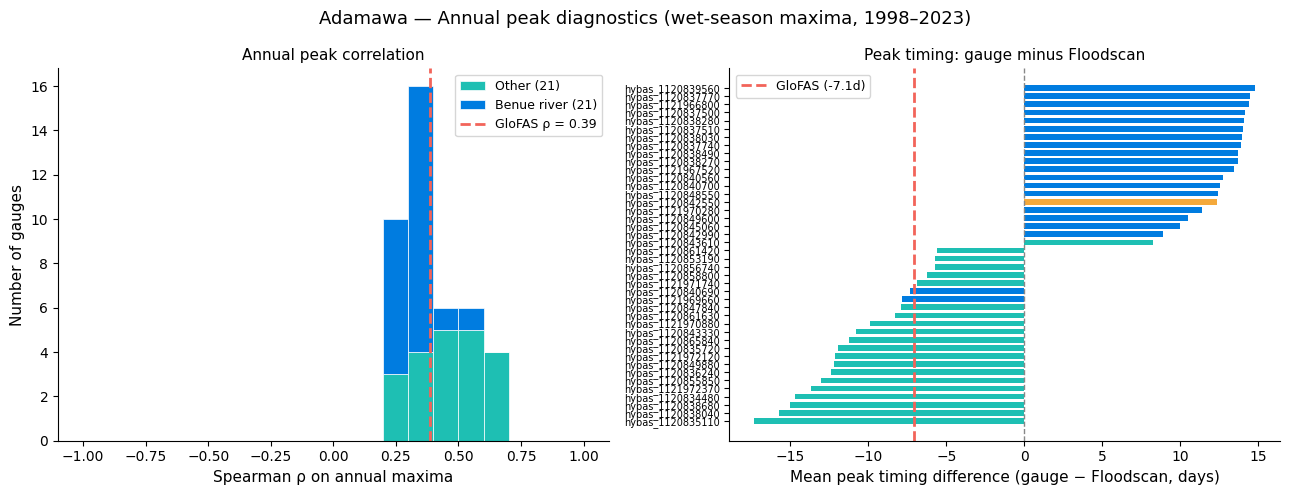

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"{STATE} — Annual peak diagnostics (wet-season maxima, {ANALYSIS_START_YEAR}–{ANALYSIS_END_YEAR})",
    fontsize=13,
)

# ── Left: histogram of annual peak ρ ─────────────────────────────────────────
ax = axes[0]
r_pk_benue = df_peaks.loc[df_peaks["is_benue"], "annual_peak_r"].values
r_pk_other = df_peaks.loc[~df_peaks["is_benue"], "annual_peak_r"].values
bins_r = np.linspace(-1, 1, 21)
ax.hist(
    [r_pk_other, r_pk_benue], bins=bins_r,
    color=["#1EBFB3", "#007CE0"], edgecolor="white", linewidth=0.5,
    label=[f"Other ({len(r_pk_other)})", f"Benue river ({len(r_pk_benue)})"],
    histtype="barstacked",
)
ax.axvline(gf_peak_r, color="#F2645A", linewidth=2, linestyle="--", label=f"GloFAS ρ = {gf_peak_r:.2f}")
ax.set_xlabel("Spearman ρ on annual maxima", fontsize=11)
ax.set_ylabel("Number of gauges", fontsize=11)
ax.set_title("Annual peak correlation", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── Right: mean peak timing difference per gauge ──────────────────────────────
ax = axes[1]
df_plot = df_peaks.sort_values("mean_peak_diff_days").reset_index(drop=True)
colors_plot = df_plot.apply(
    lambda r: CAT_COLORS["Google (high confidence)"] if r["quality_verified"]
    else CAT_COLORS["Google (Benue)"] if r["is_benue"]
    else CAT_COLORS["Google (non-Benue)"],
    axis=1,
)
ax.barh(
    range(len(df_plot)), df_plot["mean_peak_diff_days"],
    color=colors_plot, edgecolor="none", height=0.7,
)
ax.axvline(0, color="#888888", linewidth=1, linestyle="--")
ax.axvline(
    gf_mean_peak_diff, color=CAT_COLORS["GloFAS"], linewidth=2, linestyle="--",
    label=f"GloFAS ({gf_mean_peak_diff:+.1f}d)",
)
ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot["gauge_id"], fontsize=7)
ax.set_xlabel("Mean peak timing difference (gauge − Floodscan, days)", fontsize=11)
ax.set_title("Peak timing: gauge minus Floodscan", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_annual_peak_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

In [127]:
# Save all gauges with top_10 flag and lat/lon for the dashboard map
gdf_coords = gdf_stations[["gauge_id", "latitude", "longitude"]]
df_all = df_google[["gauge_id", "quality_verified", "is_benue", "best_r", "best_lag", "n_obs"]].copy()
df_all = df_all.merge(gdf_coords, on="gauge_id", how="left")
df_all["top_10"] = df_all.index < 10  # df_google is sorted by best_r desc

blob_path = f"ds-aa-nga-flooding/processed/model_comparison/{STATE.lower()}_top10_gauges.parquet"
stratus.upload_parquet_to_blob(df_all, blob_path)
print(f"Saved {len(df_all)} gauges to {blob_path}")

df_top10 = df_all[df_all["top_10"]].drop(columns=["latitude", "longitude"])
print(f"\nTop 10 Google gauges by Spearman ρ — {STATE}")
df_top10

Saved 42 gauges to ds-aa-nga-flooding/processed/model_comparison/adamawa_top10_gauges.parquet

Top 10 Google gauges by Spearman ρ — Adamawa


,gauge_id,quality_verified,is_benue,best_r,best_lag,n_obs,top_10
0,hybas_1120842990,False,True,0.742777,-4,3172,True
1,hybas_1120843610,False,False,0.742107,-4,3172,True
2,hybas_1120845060,False,True,0.735844,-5,3172,True
3,hybas_1120849600,False,True,0.732073,-5,3172,True
4,hybas_1120848550,False,True,0.730771,-5,3172,True
5,hybas_1121970280,False,True,0.728791,-6,3172,True
6,hybas_1120842550,True,True,0.725883,-6,3172,True
7,hybas_1120840700,False,True,0.725658,-6,3172,True
8,hybas_1120840560,False,True,0.725586,-6,3172,True
9,hybas_1120837770,False,True,0.718161,-7,3172,True


## Plots

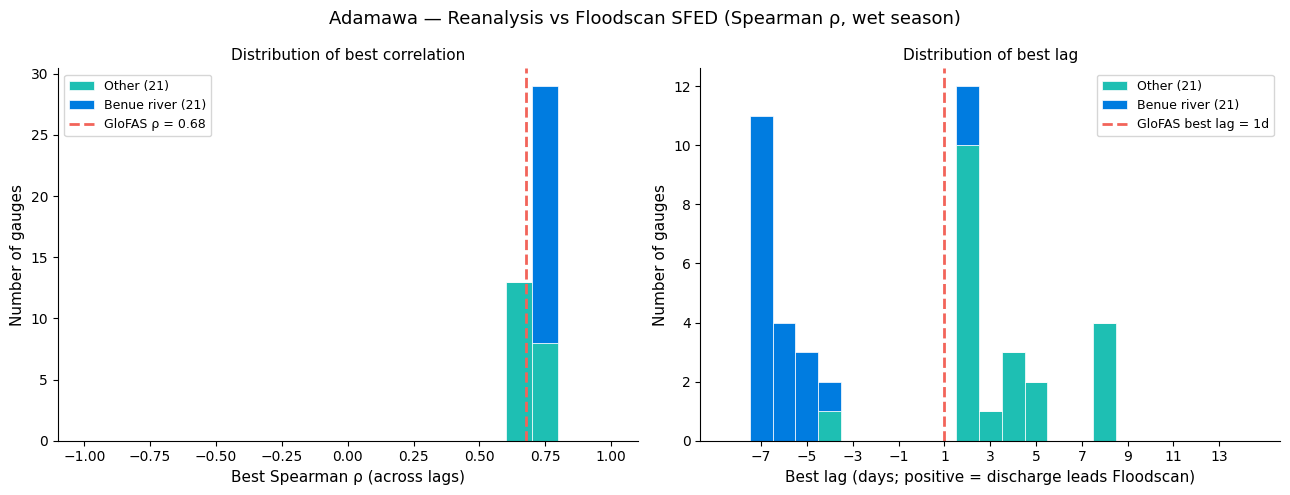

In [128]:
r_benue = df_google.loc[df_google["is_benue"], "best_r"].values
r_other = df_google.loc[~df_google["is_benue"], "best_r"].values
lag_benue = df_google.loc[df_google["is_benue"], "best_lag"].values
lag_other = df_google.loc[~df_google["is_benue"], "best_lag"].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"{STATE} — Reanalysis vs Floodscan SFED (Spearman ρ, wet season)", fontsize=13)

# ── Left: distribution of best_r per Google gauge ─────────────────────────────
ax = axes[0]
bins_r = np.linspace(-1, 1, 21)
ax.hist(
    [r_other, r_benue], bins=bins_r,
    color=["#1EBFB3", "#007CE0"], edgecolor="white", linewidth=0.5,
    label=[f"Other ({len(r_other)})", f"Benue river ({len(r_benue)})"],
    histtype="barstacked",
)
ax.axvline(gf_best_r, color="#F2645A", linewidth=2, linestyle="--", label=f"GloFAS ρ = {gf_best_r:.2f}")
ax.set_xlabel("Best Spearman ρ (across lags)", fontsize=11)
ax.set_ylabel("Number of gauges", fontsize=11)
ax.set_title("Distribution of best correlation", fontsize=11)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

# ── Right: distribution of best lag per Google gauge ──────────────────────────
ax = axes[1]
bins_lag = range(MIN_LAG - 1, MAX_LAG + 2)
ax.hist(
    [lag_other, lag_benue], bins=bins_lag,
    color=["#1EBFB3", "#007CE0"], edgecolor="white", linewidth=0.5,
    label=[f"Other ({len(lag_other)})", f"Benue river ({len(lag_benue)})"],
    histtype="barstacked", align="left",
)
ax.axvline(gf_best_lag, color="#F2645A", linewidth=2, linestyle="--",
           label=f"GloFAS best lag = {gf_best_lag}d")
ax.set_xlabel("Best lag (days; positive = discharge leads Floodscan)", fontsize=11)
ax.set_ylabel("Number of gauges", fontsize=11)
ax.set_title("Distribution of best lag", fontsize=11)
ax.set_xticks(range(MIN_LAG, MAX_LAG + 1, 2))
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_corr_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

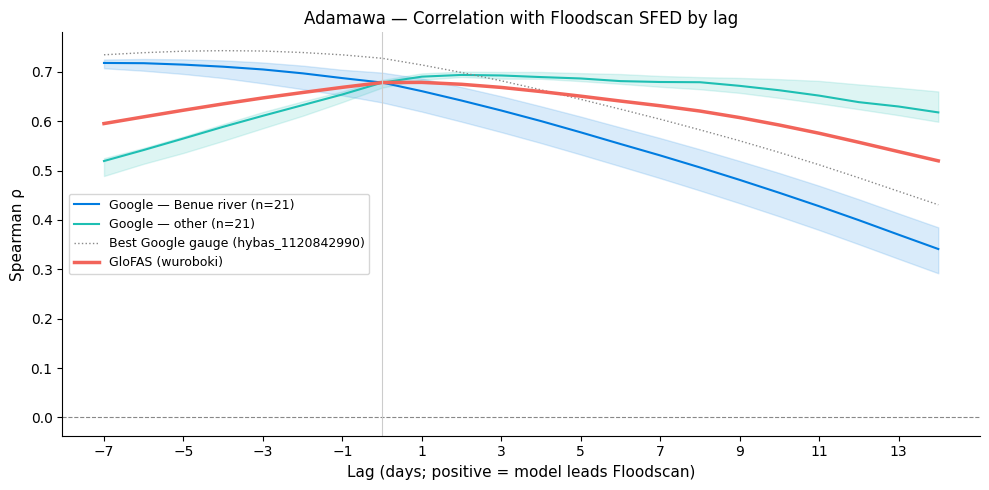

In [129]:
lags = list(range(MIN_LAG, MAX_LAG + 1))

def lag_profile_matrix(df_subset):
    return np.array(
        [[row["lag_profile"].get(lag, np.nan) for lag in lags] for _, row in df_subset.iterrows()],
        dtype=float,
    )

arr_benue = lag_profile_matrix(df_google[df_google["is_benue"]])
arr_other = lag_profile_matrix(df_google[~df_google["is_benue"]])

best_gauge_idx = df_google["best_r"].idxmax()
best_gauge_profile = [df_google.loc[best_gauge_idx, "lag_profile"].get(lag, np.nan) for lag in lags]
gf_profile = [gf_lag_profile.get(lag, np.nan) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 5))

if len(arr_benue):
    ax.fill_between(lags,
        np.nanpercentile(arr_benue, 25, axis=0), np.nanpercentile(arr_benue, 75, axis=0),
        color="#007CE0", alpha=0.15)
    ax.plot(lags, np.nanmedian(arr_benue, axis=0), color="#007CE0", linewidth=1.5,
            label=f"Google — Benue river (n={len(arr_benue)})")

if len(arr_other):
    ax.fill_between(lags,
        np.nanpercentile(arr_other, 25, axis=0), np.nanpercentile(arr_other, 75, axis=0),
        color="#1EBFB3", alpha=0.15)
    ax.plot(lags, np.nanmedian(arr_other, axis=0), color="#1EBFB3", linewidth=1.5,
            label=f"Google — other (n={len(arr_other)})")

ax.plot(lags, best_gauge_profile, color="#888888", linewidth=1, linestyle=":",
        label=f"Best Google gauge ({df_google.loc[best_gauge_idx, 'gauge_id']})")
ax.plot(lags, gf_profile, color="#F2645A", linewidth=2.5, label=f"GloFAS ({cfg['glofas_station']})")

ax.axhline(0, color="#888888", linewidth=0.8, linestyle="--")
ax.axvline(0, color="#cccccc", linewidth=0.8)
ax.set_xlabel("Lag (days; positive = model leads Floodscan)", fontsize=11)
ax.set_ylabel("Spearman ρ", fontsize=11)
ax.set_title(f"{STATE} — Correlation with Floodscan SFED by lag", fontsize=12)
ax.set_xticks(range(MIN_LAG, MAX_LAG + 1, 2))
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_corr_lag_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

In [130]:
# Summary table
summary = pd.DataFrame([
    {
        "Model": "GloFAS reanalysis",
        "Source": cfg["glofas_station"].capitalize(),
        "Best ρ": round(gf_best_r, 3),
        "Best lag (days)": gf_best_lag,
    },
    {
        "Model": "Google GRRR (median)",
        "Source": f"{len(df_google)} gauges",
        "Best ρ": round(df_google["best_r"].median(), 3),
        "Best lag (days)": int(df_google["best_lag"].median()),
    },
    {
        "Model": "Google GRRR (best gauge)",
        "Source": df_google.loc[best_gauge_idx, "gauge_id"],
        "Best ρ": round(df_google.loc[best_gauge_idx, "best_r"], 3),
        "Best lag (days)": df_google.loc[best_gauge_idx, "best_lag"],
    },
])
summary

,Model,Source,Best ρ,Best lag (days)
0,GloFAS reanalysis,Wuroboki,0.679,1
1,Google GRRR (median),42 gauges,0.706,2
2,Google GRRR (best gauge),hybas_1120842990,0.743,-4


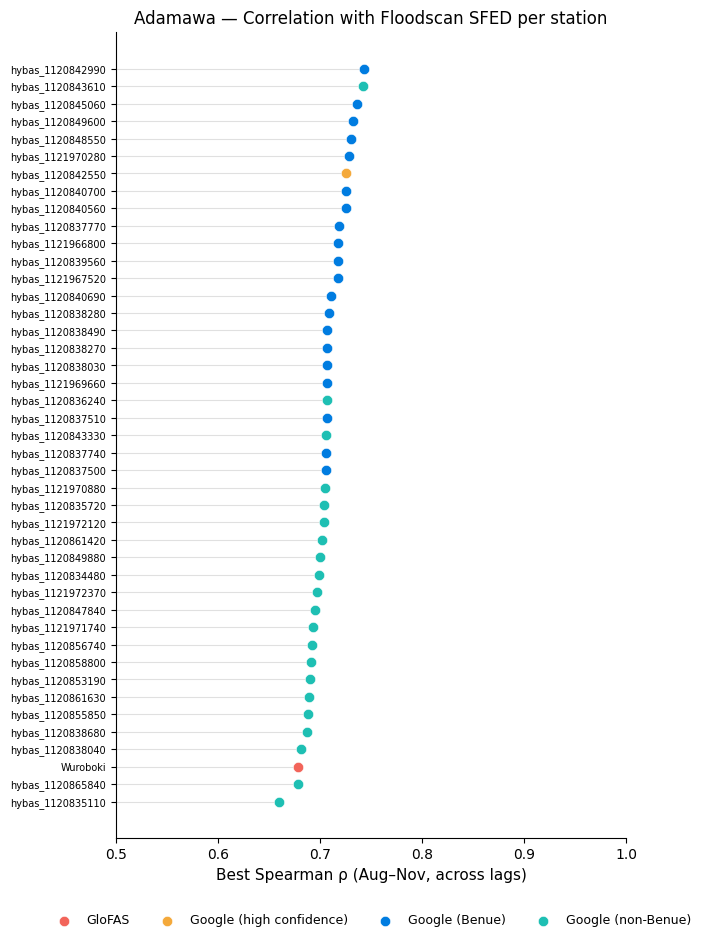

In [131]:
CAT_COLORS = {
    "GloFAS":                  "#F2645A",
    "Google (high confidence)": "#F4A93B",
    "Google (Benue)":           "#007CE0",
    "Google (non-Benue)":       "#1EBFB3",
}

def get_category(row):
    if row["quality_verified"]:
        return "Google (high confidence)"
    elif row["is_benue"]:
        return "Google (Benue)"
    else:
        return "Google (non-Benue)"

df_dot = df_google[["gauge_id", "best_r", "quality_verified", "is_benue"]].copy()
df_dot["category"] = df_dot.apply(get_category, axis=1)

gf_row = pd.DataFrame([{
    "gauge_id": cfg["glofas_station"].capitalize(),
    "best_r": gf_best_r,
    "quality_verified": False,
    "is_benue": False,
    "category": "GloFAS",
}])

df_dot = (
    pd.concat([df_dot, gf_row], ignore_index=True)
    .sort_values("best_r", ascending=True)
    .reset_index(drop=True)
)

X_MIN, X_MAX = 0.5, 1.0

fig, ax = plt.subplots(figsize=(7, max(5, len(df_dot) * 0.22)))

for i, row in df_dot.iterrows():
    color = CAT_COLORS[row["category"]]
    ax.hlines(i, X_MIN, row["best_r"], color="#e0e0e0", linewidth=0.8, zorder=1)
    ax.scatter(row["best_r"], i, color=color, s=55, zorder=3, edgecolors="white", linewidths=0.4)

ax.set_xlim(X_MIN, X_MAX)
ax.set_yticks(range(len(df_dot)))
ax.set_yticklabels(df_dot["gauge_id"], fontsize=7)
ax.set_xlabel("Best Spearman ρ (Aug–Nov, across lags)", fontsize=11)
ax.set_title(f"{STATE} — Correlation with Floodscan SFED per station", fontsize=12)

handles = [
    plt.scatter([], [], color=color, s=55, label=cat, edgecolors="white", linewidths=0.4)
    for cat, color in CAT_COLORS.items()
]
ax.legend(
    handles=handles, ncol=len(CAT_COLORS),
    loc="upper center", bbox_to_anchor=(0.5, -0.08),
    fontsize=9, frameon=False,
)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_corr_dot_plot.png", dpi=150, bbox_inches="tight")
plt.show()

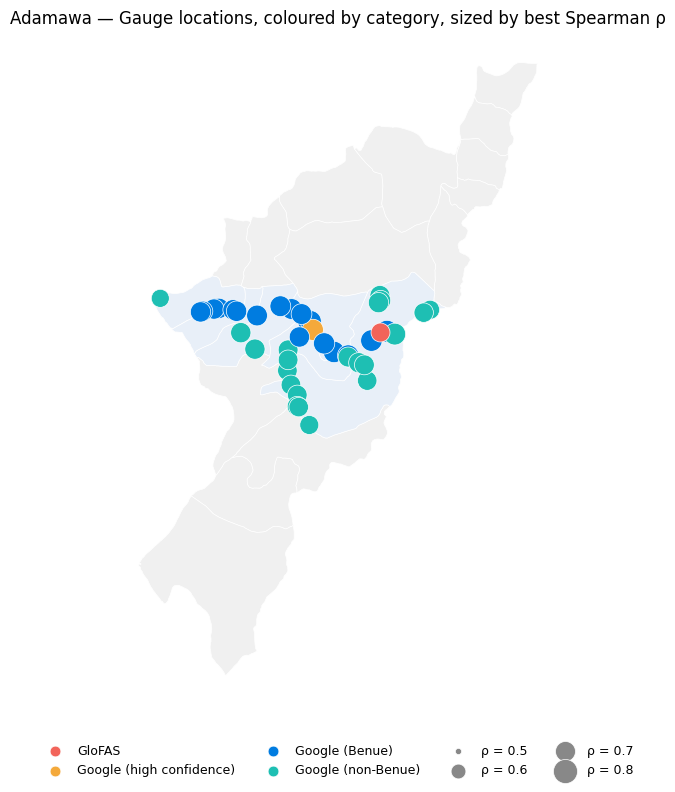

In [132]:
gdf_state = gdf_lga[gdf_lga[cfg["adm1_col"]] == cfg["adm1_val"]].copy()
gdf_non_selected = gdf_state[~gdf_state["ADM2_PCODE"].isin(cfg["lga_pcodes"])]

gdf_gauge_map = gdf_stations.merge(
    df_google[["gauge_id", "best_r", "is_benue"]],
    on="gauge_id", how="inner",
)
gdf_gauge_map["category"] = gdf_gauge_map.apply(get_category, axis=1)
gdf_gauge_map["color"] = gdf_gauge_map["category"].map(CAT_COLORS)

R_MIN, R_MAX = 0.5, 0.8
SIZE_MIN, SIZE_MAX = 20, 300

def r_to_size(r):
    return SIZE_MIN + (np.clip(r, R_MIN, R_MAX) - R_MIN) / (R_MAX - R_MIN) * (SIZE_MAX - SIZE_MIN)

gdf_gauge_map["markersize"] = gdf_gauge_map["best_r"].apply(r_to_size)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_non_selected.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_selected.plot(ax=ax, color="#E8EFF8", edgecolor="white", linewidth=0.5)

ax.scatter(
    gdf_gauge_map.geometry.x,
    gdf_gauge_map.geometry.y,
    c=gdf_gauge_map["color"],
    s=gdf_gauge_map["markersize"],
    zorder=5,
    edgecolors="white",
    linewidths=0.5,
)

# GloFAS station
gf_coords = GF_STATIONS[cfg["glofas_station"]]
ax.scatter(
    gf_coords["lon"], gf_coords["lat"],
    c=CAT_COLORS["GloFAS"],
    s=r_to_size(gf_best_r),
    zorder=6,
    edgecolors="white",
    linewidths=0.5,
)

# Category legend
for cat, color in CAT_COLORS.items():
    ax.scatter([], [], color=color, s=60, label=cat, edgecolors="white", linewidths=0.5)

# Size legend
for r_val in [0.5, 0.6, 0.7, 0.8]:
    ax.scatter([], [], color="#888888", s=r_to_size(r_val),
               label=f"ρ = {r_val:.1f}", edgecolors="white", linewidths=0.5)

ax.legend(
    ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.04),
    fontsize=9, frameon=False,
)
ax.set_axis_off()
ax.set_title(f"{STATE} — Gauge locations, coloured by category, sized by best Spearman ρ", fontsize=12)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{STATE.lower()}_corr_gauge_map.png", dpi=150, bbox_inches="tight")
plt.show()